# University Intent Classification
Fine-tuning `bert-base-uncased` for student query routing.

**Run cells top to bottom. After training, the model is saved to `../model/`.**

## 1. Install Dependencies

In [35]:
# Run this once, then restart kernel if needed
# !pip install transformers torch datasets scikit-learn pandas matplotlib seaborn

In [36]:
# import subprocess, sys

# packages = [
#     "transformers",
#     "torch",
#     "datasets",
#     "scikit-learn",
#     "pandas",
#     "matplotlib",
#     "seaborn",
#     "streamlit",
# ]

# subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

In [37]:
import os
print(os.getcwd())

/content


## 2. Imports

In [38]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 3. Load & Explore Data

In [ ]:
# For Local Device
TRAIN_PATH = Path.cwd().parent / "dataset" / "university_query_train.csv"
TEST_PATH = Path.cwd().parent / "dataset" / "university_query_test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# For Google Colab
# train_df = pd.read_csv("dataset/university_query_train.csv")
# test_df = pd.read_csv("dataset/university_query_test.csv")

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
print()
print('Train columns:', train_df.columns.tolist())
train_df.head()

Train shape: (5000, 5)
Test shape:  (1000, 5)

Train columns: ['Query_ID', 'Student_Query', 'Department', 'Days_To_Deadline', 'Priority_Label']


,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,I cannot download my hall ticket for tomorrow'...,Administration,43,High


In [ ]:
# ── Adjust these two lines to match your actual column names ──────────────
# Ganti sesuai isi column
TEXT_COL  = 'Student_Query'
LABEL_COL = 'Department'
# ─────────────────────────────────────────────────────────────────────────

# Auto-detect if the defaults don't exist
if TEXT_COL not in train_df.columns or LABEL_COL not in train_df.columns:
    print('Column names found:', train_df.columns.tolist())
    print('Update TEXT_COL and LABEL_COL above to match!')
else:
    print('Labels found in dataset:')
    print(train_df[LABEL_COL].value_counts())

Labels found in dataset:
Department
Examination Cell    770
Hostel Office       758
Administration      734
Academic Office     712
IT Support          704
Finance Office      664
Library             658
Name: count, dtype: int64


In [41]:
print(train_df.columns)

Index(['Query_ID', 'Student_Query', 'Department', 'Days_To_Deadline',
       'Priority_Label'],
      dtype='object')


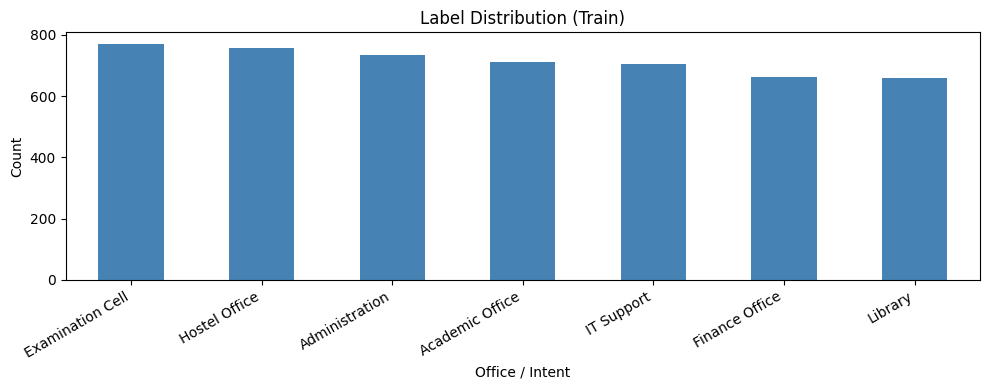

In [42]:
# Label distribution plot
plt.figure(figsize=(10, 4))
train_df[LABEL_COL].value_counts().plot(kind='bar', color='steelblue')
plt.title('Label Distribution (Train)')
plt.xlabel('Office / Intent')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [43]:
# Encode string labels → integers
le = LabelEncoder()
train_df['label_id'] = le.fit_transform(train_df[LABEL_COL])
test_df['label_id']  = le.transform(test_df[LABEL_COL])

NUM_LABELS = len(le.classes_)
print(f'Number of classes: {NUM_LABELS}')
print('Class mapping:')
for i, c in enumerate(le.classes_):
    print(f'  {i} → {c}')

Number of classes: 7
Class mapping:
  0 → Academic Office
  1 → Administration
  2 → Examination Cell
  3 → Finance Office
  4 → Hostel Office
  5 → IT Support
  6 → Library


In [44]:
# Drop rows with missing text
train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
test_df  = test_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print('After dropping NaN — Train:', len(train_df), '| Test:', len(test_df))

After dropping NaN — Train: 5000 | Test: 1000


## 5. Dataset & DataLoader

In [45]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 16

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IntentDataset(train_df[TEXT_COL], train_df['label_id'], tokenizer, MAX_LEN)
test_dataset  = IntentDataset(test_df[TEXT_COL],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train batches: 313 | Test batches: 63


## 6. Model Setup

In [46]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(DEVICE)

EPOCHS    = 4
LR        = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 1252


## 7. Training

In [47]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='Training'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds  = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds  = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return total_loss / len(loader), correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc = eval_epoch(model, test_loader, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch}/{EPOCHS} '
          f'| train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| val loss {vl_loss:.4f} acc {vl_acc:.4f}')

Training:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/4 | train loss 1.9580 acc 0.1450 | val loss 1.9521 acc 0.1430


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/4 | train loss 1.9476 acc 0.1512 | val loss 1.9494 acc 0.1340


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/4 | train loss 1.9447 acc 0.1546 | val loss 1.9492 acc 0.1500


## 8. Training Curves

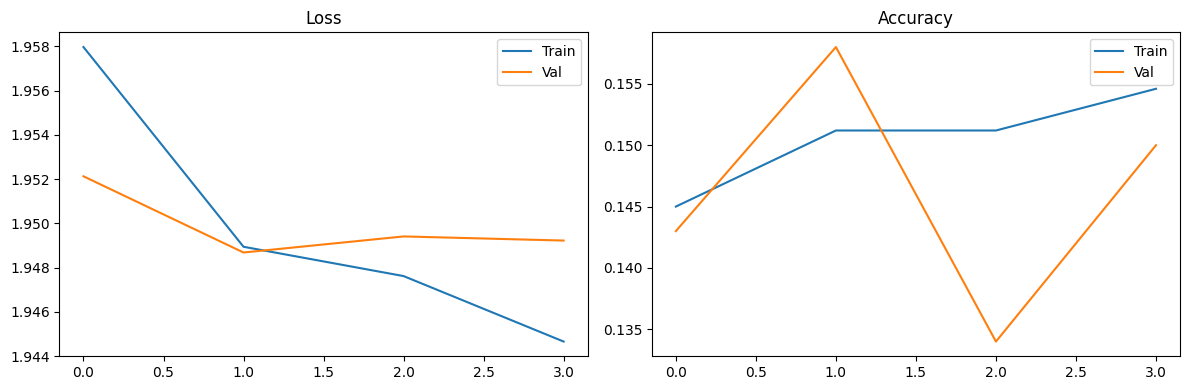

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation

In [49]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))

                  precision    recall  f1-score   support

 Academic Office       0.13      0.06      0.08       154
  Administration       0.16      0.08      0.11       147
Examination Cell       0.14      0.55      0.22       132
  Finance Office       0.00      0.00      0.00       149
   Hostel Office       0.17      0.40      0.24       141
      IT Support       0.00      0.00      0.00       147
         Library       0.00      0.00      0.00       130

        accuracy                           0.15      1000
       macro avg       0.09      0.16      0.09      1000
    weighted avg       0.09      0.15      0.09      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


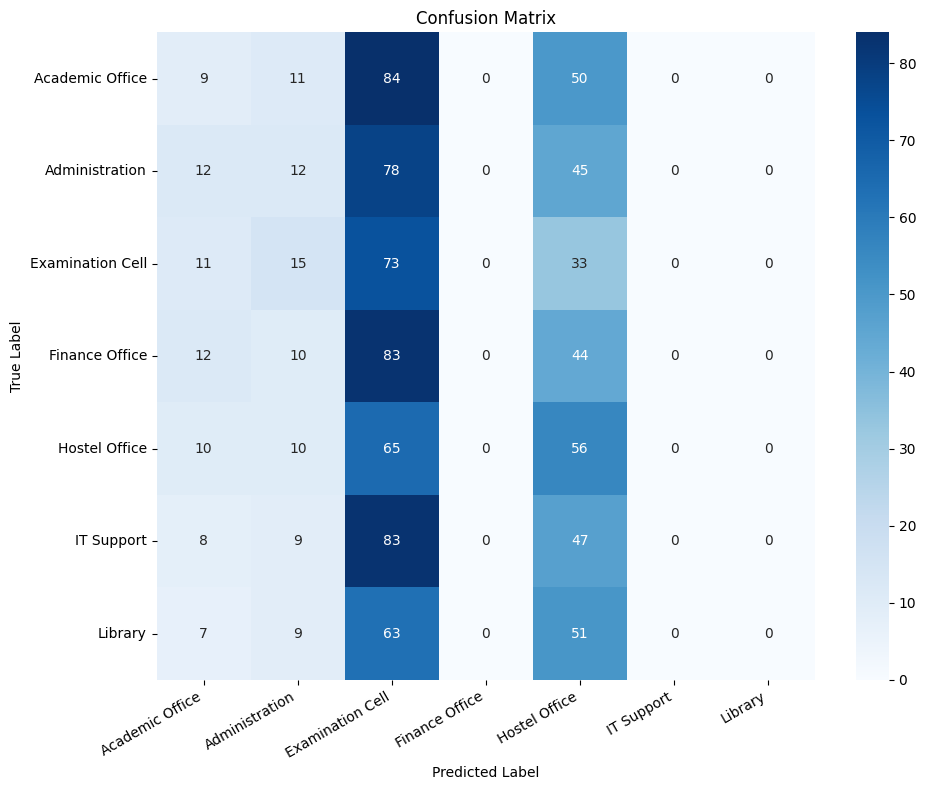

In [50]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Save Model + Label Mapping

In [51]:
SAVE_DIR = '../model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save BERT weights + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping so app.py can decode predictions
label_map = {str(i): label for i, label in enumerate(le.classes_)}
with open(os.path.join(SAVE_DIR, 'label_map.json'), 'w') as f:
    json.dump(label_map, f, indent=2)

print('Saved to', SAVE_DIR)
print('Label map:', label_map)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ../model
Label map: {'0': 'Academic Office', '1': 'Administration', '2': 'Examination Cell', '3': 'Finance Office', '4': 'Hostel Office', '5': 'IT Support', '6': 'Library'}


## 11. Quick Sanity Check
Test a few example queries before launching the app.

In [52]:
def predict(text, model, tokenizer, label_map, device, max_len=128):
    model.eval()
    enc = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
    pred_id = outputs.logits.argmax(dim=1).item()
    probs   = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
    return label_map[str(pred_id)], float(probs[pred_id])


sample_queries = [
    'I have not received my scholarship payment yet',
    'My student email account is not working',
    'I want to request a transcript',
    'When is the deadline to add or drop a course?',
    'The WiFi in the dorm keeps disconnecting',
]

for q in sample_queries:
    intent, conf = predict(q, model, tokenizer, label_map, DEVICE)
    print(f'  [{conf:.0%}] "{q}"')
    print(f'        → {intent}\n')

  [16%] "I have not received my scholarship payment yet"
        → Hostel Office

  [16%] "My student email account is not working"
        → Hostel Office

  [16%] "I want to request a transcript"
        → Examination Cell

  [15%] "When is the deadline to add or drop a course?"
        → Hostel Office

  [16%] "The WiFi in the dorm keeps disconnecting"
        → Examination Cell

